# Fashion MNIST 데이터셋 이미지 분류

# Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
import keras

In [2]:
tf.__version__

'2.19.0'

In [3]:
keras.__version__

'3.13.2'

In [4]:
print(tf.config.list_physical_devices())  # CPU/GPU/TPU 사용 여부 확인

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [5]:
print(keras.config.backend())  # keras 라이브러리에서 텐서 연산을 할 때 필요한 라이브러리.

tensorflow


Keras 라이브러리는 텐서 연산을 직접 수행하지 않음. 대신에 텐서 연산을 수행하는 다른 딥러닝 라이브러리를 백엔드(backend)로 활용함.

*   Keras에서 사용하는 백엔드 종류
        *   TensorFlow - 구글에서 만든 텐서 연산 라이브러리.
        *   PyTorch - 메타에서 만든 딥러닝 라이브러리 -> 리눅스 재단으로 이전, 오픈소스로 공개됨.
*   Keras
    *   여러가지 백엔드를 사용해서 신견망을 쉽게 만들고 훈련할 수 있도록 만든 고급 라이브러리.
    *   2.3.1 버전 이후부터는 TensorFlow만 단일 백엔드로 사용하도록 기능 변경.
    *   3.0 버전부터 다시 멀티 백엔드 정책으로 바뀜.

# Fashion MNIST 데이터 셋

10개 클래스(예: 바지, 셔츠, 구두, ...)의 패션 아이템 28 * 28. 60,000개 훈련 셋/레이블, 10,000개 테스트 셋/레이블.

In [6]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
x_train.shape #> (n_samples, width, height)

(60000, 28, 28)

In [11]:
y_train.shape  #> (n_samples)

(60000,)

In [13]:
x_test.shape

(10000, 28, 28)

In [15]:
y_test.shape

(10000,)

In [18]:
# 훈련 레이블의 중복되지 않는 값들 개수
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [19]:
# 테스트 레이블의 중복되지 않는 값들
np.unique(y_test, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

훈련 셋과 테스트 셋 모두 각 클래스의 샘플들이 같은 개수로 수집되어 있음.

In [22]:
x_train[0]  #> 0(black) ~ 255(white) scale의 28*28 크기의 흑백 이미지.

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

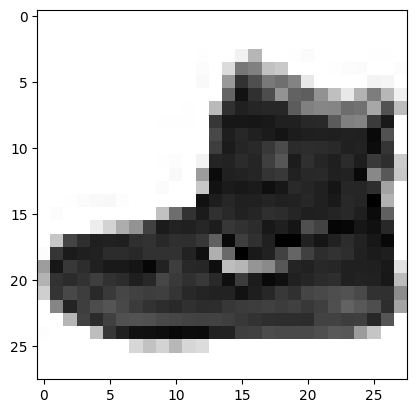

In [24]:
plt.imshow(x_train[0], cmap=plt.cm.binary)

In [27]:
def plot_fashion_mnist(arr, ncols=10):
    # arr (n_samples, width, height) shape의 3차원 배열
    # ncols: subplot axis의 컬럼 개수.
    n = len(arr)  # 출력할 이미지 개수
    nrows = int(np.ceil(n / ncols))  # subplot axis의 행 개수
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols, nrows))
    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j  # 배열 arr에서 선택할 이미지의 인덱스
            if nrows == 1 or ncols == 1: # axes는 1차원 배열
                if idx < n:
                    axes[idx].imshow(arr[idx], cmap=plt.cm.binary)
                axes[idx].axis('off')
            else:  # axes는 2차원 배열
                if idx < n:
                    axes[i, j].imshow(arr[idx], cmap=plt.cm.binary)
                axes[i, j].axis('off')
    plt.show()

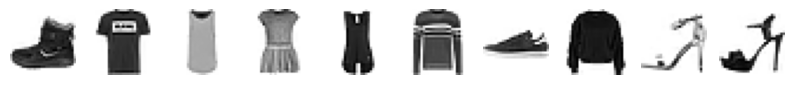

In [28]:
plot_fashion_mnist(x_train[:10])

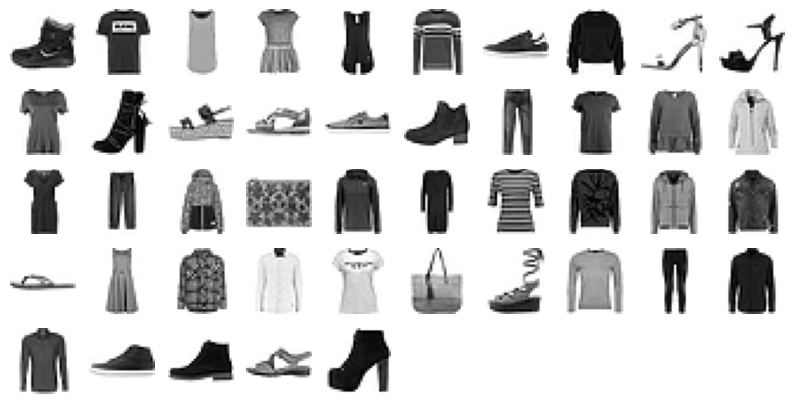

In [30]:
plot_fashion_mnist(x_train[:45])

# 훈련 셋 스케일링, 훈련/검증 분리

In [31]:
# 훈련 셋의 스케일을 0 ~ 1 사이의 값으로 변경. -> SGDClassifier의 성능 향상을 위해서
x_train_scaled = x_train / 255

In [32]:
# 훈련 셋과 훈련 레이블을 훈련/검증으로 분리
train_input, val_input, train_target, val_target = train_test_split(x_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [33]:
train_input.shape

(48000, 28, 28)

In [34]:
train_target.shape

(48000,)

# SGD Classifier

In [35]:
sgd = SGDClassifier(loss='log_loss', random_state=42, n_jobs=-1)  # 모델 생성

In [37]:
# 모델 훈련 - (주의) 훈련 셋은 (n_samples, n_features) shape의 2차원 배열이어야 함!
sgd.fit(X=train_input.reshape((48_000, -1)), y=train_target)

SGDClassifier(loss='log_loss', n_jobs=-1, random_state=42)

In [39]:
sgd.coef_.shape

(10, 784)

In [40]:
sgd.intercept_.shape

(10,)

In [41]:
# 각 클래스가 될 확률
predict_probs = sgd.predict_proba(X=train_input.reshape((48_000, -1)))

In [42]:
predict_probs[:2]

array([[1.20888251e-02, 1.05549631e-05, 2.30094285e-01, 3.41231387e-03,
        4.86284532e-02, 3.96063160e-10, 6.91742929e-01, 1.54454383e-17,
        1.40226378e-02, 1.05805064e-16],
       [7.53889861e-01, 1.20438290e-04, 4.89841116e-05, 2.88644150e-04,
        7.52168267e-02, 4.15812599e-17, 1.69806662e-01, 2.22627871e-15,
        6.28584469e-04, 3.41774283e-15]])

In [43]:
predicts = sgd.predict(X=train_input.reshape((48_000, -1)))

In [44]:
predicts[:2]

array([6, 0], dtype=uint8)

In [45]:
accuracy_score(y_true=train_target, y_pred=predicts)  # 훈련 셋 정확도

0.8518125

In [47]:
# 검증 셋 평가
val_input_2d = val_input.reshape((12_000, -1))  # 3d 배열 -> 2d 배열
val_predicts = sgd.predict(X=val_input_2d)  # 검증 셋 예측값
accuracy_score(y_true=val_target, y_pred=val_predicts)  # 검증 셋 정확도

0.8468333333333333

# 입력층과 출력층만 갖는 신경망

In [48]:
train_input_2d = train_input.reshape((48_000, -1))
train_input_2d.shape

(48000, 784)

In [49]:
# 입력층(input layer)
inputs = keras.Input(shape=(784,))

In [50]:
# 출력층(output layer)
dense = keras.layers.Dense(units=10, activation='softmax')

In [51]:
# 완전연결 신경망
model = keras.Sequential(layers=[inputs, dense])

In [52]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
# 신경망 모델 컴파일
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [55]:
# 신경망 모델 훈련
model.fit(x=train_input_2d, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.0359 - sparse_categorical_accuracy: 0.6796
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7071 - sparse_categorical_accuracy: 0.7747
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6368 - sparse_categorical_accuracy: 0.7952
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5983 - sparse_categorical_accuracy: 0.8061
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5728 - sparse_categorical_accuracy: 0.8139
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5543 - sparse_categorical_accuracy: 0.8197
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5402 - sparse_categorical_accuracy: 0.8229
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5286 - sparse_categorical_accuracy: 0.8261
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5193 - sparse_categorical_accuracy: 0.8289
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - 

In [56]:
# 훈련된 신경망 모델이 찾은 모델 파라미터들(가중치, weights)
model.weights

[<Variable path=sequential/dense/kernel, shape=(784, 10), dtype=float32, value=[[-0.04793017 -0.01703254  0.0048259  ...  0.05326931 -0.06812719
   -0.06745771]
  [ 0.02102584  0.02527655  0.05806005 ... -0.05049906  0.03882771
    0.06727601]
  [-0.05411176 -0.05617603 -0.00395058 ...  0.01347071 -0.07493529
    0.07763229]
  ...
  [-0.06566445 -0.00198313  0.03128767 ... -0.06661069 -0.03371427
    0.0722779 ]
  [-0.02560487  0.03776513 -0.05120555 ...  0.01606558  0.03660117
   -0.02099758]
  [-0.0329545   0.0651206  -0.0645705  ... -0.02924526  0.01204377
   -0.04358605]]>,
 <Variable path=sequential/dense/bias, shape=(10,), dtype=float32, value=[ 0.12213957 -0.10329405 -0.10312269  0.02325196 -0.4762941   1.1300837
   0.22987492 -0.08311307 -0.2533357  -0.4861893 ]>]

In [57]:
predicts = model.predict(x=train_input_2d)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [59]:
predicts.shape  #> (48_000, 10) = (n_samples, n_classes)

(48000, 10)

In [60]:
predicts[:2]

array([[7.9250988e-03, 4.7625357e-04, 1.8821748e-01, 2.0300841e-02,
        5.0666369e-02, 5.3485026e-05, 7.2607052e-01, 1.3016503e-06,
        6.2777526e-03, 1.0918183e-05],
       [5.8182734e-01, 3.7676349e-04, 2.1626230e-03, 1.2810872e-02,
        1.1798526e-02, 1.2446327e-07, 3.9063886e-01, 4.0170110e-07,
        3.8093555e-04, 3.5625778e-06]], dtype=float32)

In [61]:
# 훈련 셋의 예측 레이블 계산 - 10개의 확률들 중 최댓값의 인덱스.
train_pred_labels = predicts.argmax(axis=1)

In [62]:
train_pred_labels[:2]

array([6, 0])

In [63]:
accuracy_score(y_true=train_target, y_pred=train_pred_labels)  # 훈련 셋 정확도

0.8315

In [64]:
model.evaluate(x=train_input_2d, y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5065 - sparse_categorical_accuracy: 0.8315


[0.5064613223075867, 0.8314999938011169]

In [65]:
# 검증 셋 정확도
model.evaluate(x=val_input_2d, y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4969 - sparse_categorical_accuracy: 0.8360


[0.49689677357673645, 0.8360000252723694]

# 활성화 함수(Activation Function)

*   활성화 함수: 신경망의 각 층(layer)에서 출력을 내보내는 함수.
*   은닉층(hidden layer)에서 활성화 함수로 선형 함수를 사용하면 여러 개의 층을 연결하는 효과가 없음.
    *   단일 층을 사용하는 것과 같음.
*   은닉층에서는 비선형 함수를 활성화 함수로 사용.

## Sigmoid 함수

$
\text{sigmoid}(x) = \dfrac{1}{1 + \exp(-x)}
$

In [66]:
xvals = np.arange(-5, 5, 0.0001)

In [67]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

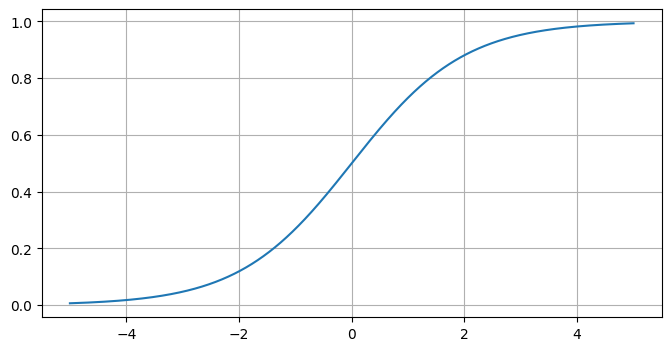

In [68]:
plt.figure(figsize=(8, 4))
plt.plot(xvals, sigmoid(xvals))
plt.grid()
plt.show()

In [69]:
def plot_activation_fn(fn):
    xvals = np.arange(-5, 5, 0.0001)
    yvals = fn(xvals)
    plt.figure(figsize=(8, 4))
    plt.plot(xvals, yvals)
    plt.grid()
    plt.show()

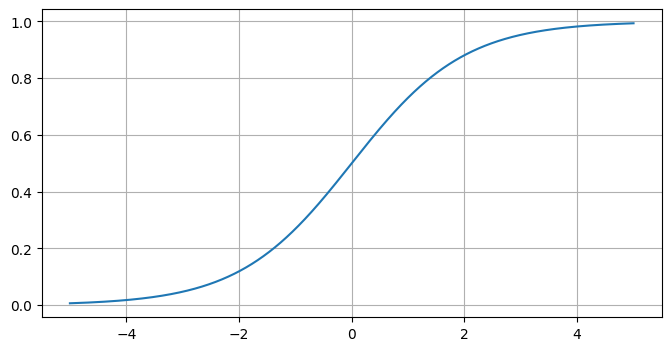

In [70]:
plot_activation_fn(sigmoid)

## Hyperbolic Tangent

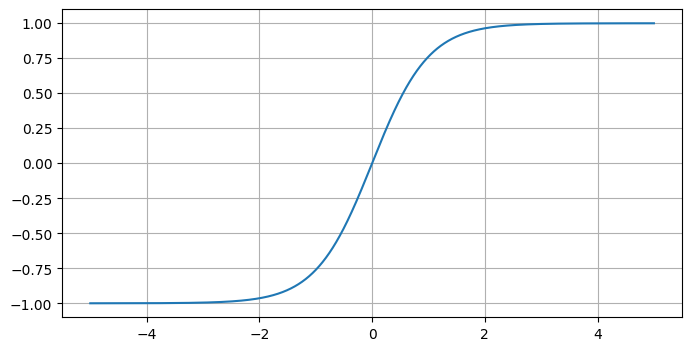

In [71]:
plot_activation_fn(np.tanh)

## ReLU(Rectified Linear Unit)

*   입력값이 양수이면 입력값 그대로 출력을 내보냄.
*   입력값이 음수이면 출력값을 0으로 만듦.
*   이미지를 처리할 때 좋은 성능을 낸다고 알려져 있음.

$
\text{ReLU}(x) =
    \begin{cases}
        x & \text{for } x \ge 0 \\
        0 & \text{for } x \lt 0
    \end{cases}
$

In [72]:
def relu(x):
    return np.maximum(x, 0)

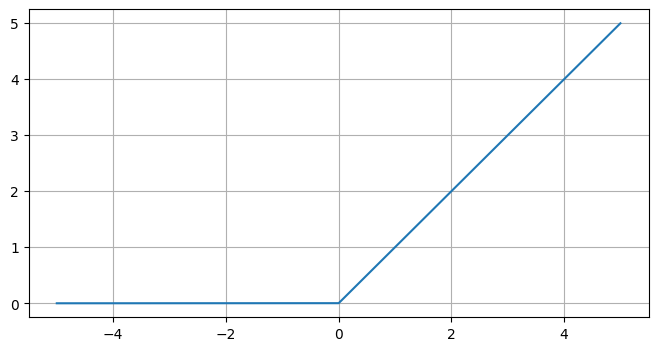

In [73]:
plot_activation_fn(relu)

## Leaky ReLU

$
\text{LeakyReLU}(x, \alpha) =
    \begin{cases}
        x & \text{for } x \ge 0 \\
        \alpha x & \text{for } x \lt 0, \alpha \ge 0
    \end{cases}
$

In [74]:
def leaky_relu(x, alpha=0.1):
    # 0 <= alpha <= 1
    return np.maximum(x, alpha * x)

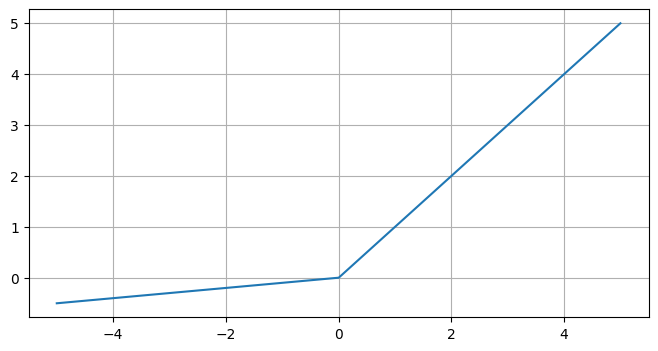

In [75]:
plot_activation_fn(leaky_relu)

## ELU(Exponential Linear Unit)

$
\text{ELU}(x, \alpha) =
    \begin{cases}
        x & \text{for } x \ge 0 \\
        \alpha (\exp(x) - 1) & \text{for } x \lt 0
    \end{cases}
$

In [80]:
def elu(x, alpha=1.0):
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))

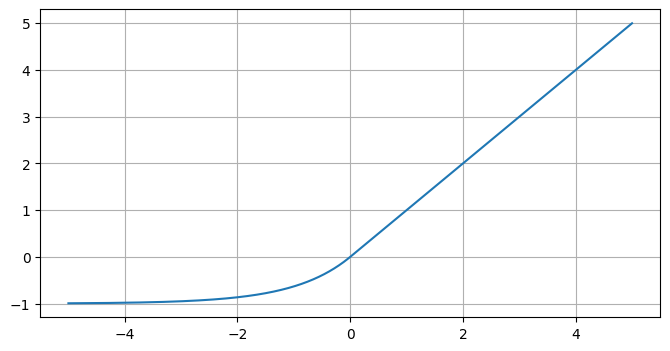

In [81]:
plot_activation_fn(elu)

은닉층에서 활성화 함수 선택: ELU > LeakyReLU > ReLU > tanh > sigmoid

# ReLU를 활성화 함수로 사용하는 은닉층

In [82]:
model = keras.Sequential()  # 완전연결 신경망

In [83]:
model.add(keras.Input(shape=(28, 28)))  # 입력층

In [84]:
# Flatten 층: (28, 28) 모양의 배열을 (784, ) 모양의 1차원 배열로 변환
model.add(keras.layers.Flatten())

In [85]:
# 은닉층: 100개의 unit들을 갖는, ReLU 활성화 함수를 사용하는 은닉층을 추가
model.add(keras.layers.Dense(units=100, activation='relu'))

In [86]:
# 출력층: 10개 클래스로 분류하는 다중 클래스 분류 문제.
model.add(keras.layers.Dense(units=10, activation='softmax'))

In [87]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [89]:
model.fit(x=train_input, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.9795 - sparse_categorical_accuracy: 0.6963
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6307 - sparse_categorical_accuracy: 0.7935
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5585 - sparse_categorical_accuracy: 0.8154
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5208 - sparse_categorical_accuracy: 0.8238
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4969 - sparse_categorical_accuracy: 0.8316
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4790 - sparse_categorical_accuracy: 0.8370
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4652 - sparse_categorical_accuracy: 0.8407
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4541 - sparse_categorical_accuracy: 0.8453
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4447 - sparse_categorical_accuracy: 0.8481
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - 

In [90]:
model.evaluate(x=train_input, y=train_target)  # 훈련 셋 평가

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4340 - sparse_categorical_accuracy: 0.8503


[0.43403905630111694, 0.8502500057220459]

In [91]:
model.evaluate(x=val_input, y=val_target)  # 검증 셋 평가

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4277 - sparse_categorical_accuracy: 0.8517


[0.42771634459495544, 0.8516666889190674]

# ELU 활성화함수 은닉층

Input --> Flatten --> Dense --> Dense

In [92]:
model = keras.Sequential()

In [93]:
model.add(keras.Input(shape=(28, 28)))

In [94]:
model.add(keras.layers.Flatten())

In [95]:
model.add(keras.layers.Dense(units=100, activation='elu'))

In [96]:
model.add(keras.layers.Dense(units=10, activation='softmax'))

In [101]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,512 (310.60 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [97]:
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [98]:
model.fit(x=train_input, y=train_target, batch_size=64, epochs=100)

Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.8916 - sparse_categorical_accuracy: 0.7188
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6039 - sparse_categorical_accuracy: 0.8013
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5428 - sparse_categorical_accuracy: 0.8183
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5111 - sparse_categorical_accuracy: 0.8280
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4904 - sparse_categorical_accuracy: 0.8327
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4762 - sparse_categorical_accuracy: 0.8362
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4640 - sparse_categorical_accuracy: 0.8397
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4549 - sparse_categorical_accuracy: 0.8431
Epoch 9/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4476 - sparse_categorical_accuracy: 0.8447
Epoch 10/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5

In [99]:
model.evaluate(x=train_input, y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2785 - sparse_categorical_accuracy: 0.9006


[0.2784726321697235, 0.9005625247955322]

In [100]:
model.evaluate(x=val_input, y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3319 - sparse_categorical_accuracy: 0.8844


[0.3319290280342102, 0.8844166398048401]